# Analisi delle anomalie climatiche globali

## Obiettivo

In questo notebook analizziamo le anomalie mensili della temperatura globale usando il dataset NASA GISTEMP v4.

L’analisi comprende:

- caricamento e pulizia dei dati;
- visualizzazione della serie temporale;
- costruzione di feature temporali e autoregressive;
- stima del trend climatico;
- previsione delle anomalie future;
- confronto tra modelli di machine learning.

## Dataset

Il dataset contiene l’anomalia mensile della temperatura globale terra-oceano, espressa in °C rispetto alla climatologia di riferimento 1951-1980.

## Preparazione dei dati

I dati vengono trasformati in formato lungo e ordinati cronologicamente. Per ogni osservazione vengono conservati:

- anno;
- mese;
- anomalia termica;
- data mensile.

## Feature engineering

A partire dalla serie temporale costruiamo:

- `t_years`: tempo trascorso dall’inizio della serie, in anni;
- `sin_month` e `cos_month`: codifica ciclica della stagionalità;
- `lag_1` fino a `lag_12`: anomalie dei dodici mesi precedenti.

I lag permettono ai modelli di utilizzare la memoria recente della serie temporale.

## Modello interpretabile

La regressione lineare stima l’anomalia in funzione del trend temporale e della stagionalità.

Il coefficiente associato a `t_years` rappresenta il trend stimato in °C/anno. Lo stesso valore viene riportato anche in °C/secolo.

## Modelli predittivi

Confrontiamo due modelli:

- regressione polinomiale di grado 2;
- random forest regression.

I dati vengono divisi cronologicamente: la parte iniziale viene usata per l’addestramento, mentre il periodo più recente viene riservato alla valutazione.

## Metriche

Le prestazioni vengono valutate usando:

- **MAE**: errore assoluto medio;
- **RMSE**: radice dell’errore quadratico medio;
- **R²**: proporzione della variabilità spiegata dal modello.

## Interpretazione

Per la random forest calcoliamo anche la permutation importance, che misura quanto peggiora la previsione quando una feature viene permutata.

Le feature più importanti indicano quali informazioni temporali contribuiscono maggiormente alla previsione delle anomalie.

## Conclusioni

I risultati devono essere interpretati distinguendo tra:

- descrizione statistica del trend osservato;
- capacità predittiva sui dati recenti;
- importanza delle feature;
- limiti dovuti alla natura temporale e non stazionaria del clima.

Un buon risultato predittivo non implica necessariamente una relazione causale.

In [40]:
from pathlib import Path
import sys
plt.rcParams['text.usetex'] = True
import matplotlib.pyplot as plt
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
print("Directory kernel:", Path.cwd())
print("Project root:", project_root)

Directory kernel: /Users/anvi/Desktop/climate_science/notebook
Project root: /Users/anvi/Desktop/climate_science


In [41]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [42]:
from funcs.climate_funcs import (
    load_gistemp,
    make_features,
    fit_inference_model,
    fit_prediction_models,
)

We want to study the function:

$Y_t = f(X_t) + \epsilon_t$

In [43]:
climate = load_gistemp()
climate.head()

,year,month_name,anomaly,month,date
0,1880,Jan,-0.19,1,1880-01-01
1,1880,Feb,-0.25,2,1880-02-01
2,1880,Mar,-0.09,3,1880-03-01
3,1880,Apr,-0.16,4,1880-04-01
4,1880,May,-0.10,5,1880-05-01


In [ ]:
climate_ml = make_features(
    climate,
    n_lags=12,
)
climate_ml.head()

,year,month_name,anomaly,month,date,t_years,sin_month,cos_month,lag_1
0,1880,Feb,-0.25,2,1880-02-01,0.084875,8.660254e-01,5.000000e-01,-0.19
1,1880,Mar,-0.09,3,1880-03-01,0.164274,1.000000e+00,6.123234e-17,-0.25
2,1880,Apr,-0.16,4,1880-04-01,0.249150,8.660254e-01,-5.000000e-01,-0.09
3,1880,May,-0.10,5,1880-05-01,0.331287,5.000000e-01,-8.660254e-01,-0.16
4,1880,Jun,-0.21,6,1880-06-01,0.416162,1.224647e-16,-1.000000e+00,-0.10


In [47]:
inference = fit_inference_model(climate_ml)

print(f"Trend stimato: "f"{inference['trend_degC_per_year']:.5f} °C/anno")
print(f"Trend stimato: "f"{inference['trend_degC_per_century']:.3f} °C/secolo")
print(f"R²: {inference['r2']:.3f}")
print(f"Deviazione standard dei residui ε: "f"{inference['residual_std_degC']:.3f} °C")

Trend stimato: 0.00838 °C/anno
Trend stimato: 0.838 °C/secolo
R²: 0.716
Deviazione standard dei residui ε: 0.223 °C


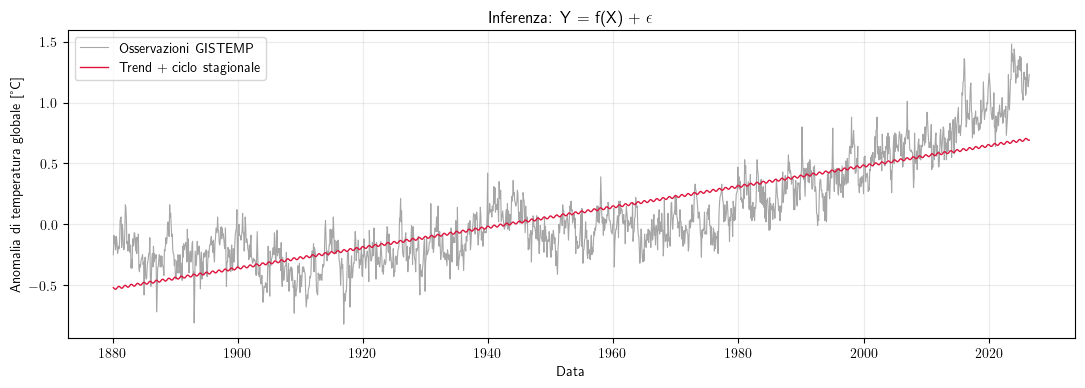

In [52]:
fig, ax = plt.subplots(figsize=(13, 4))

ax.plot(
    inference["data"]["date"],
    inference["data"]["anomaly"],
    color="0.65", linewidth=0.8, label="Osservazioni GISTEMP",
)

ax.plot(
    inference["data"]["date"],
    inference["fitted"],
    color="crimson", linewidth=1.0, label="Trend + ciclo stagionale",
)
ax.plot(dpi = 300)

ax.set_xlabel("Data")
ax.set_ylabel("Anomalia di temperatura globale [°C]")
ax.set_title(r"Inferenza: Y = f(X) + $\epsilon$")
ax.grid(alpha=0.25)
ax.legend()

plt.show()

In [53]:
prediction = fit_prediction_models(
    climate_ml,
    train_fraction=0.80,
    random_state=42,
)

prediction["metrics"]

,MAE_degC,RMSE_degC,R2
polynomial,0.099816,0.124405,0.769044
random_forest,0.379731,0.452275,-2.052539


In [54]:
prediction["random_forest_importance"].head(10)

lag_1      2.499038e-02
month      1.525490e-02
lag_2      7.751414e-03
lag_3      3.346482e-03
lag_7      1.848331e-03
lag_8      1.072817e-03
lag_9      6.347039e-04
lag_4      2.328471e-04
t_years    3.108624e-16
lag_5     -2.580249e-03
Name: permutation_importance, dtype: float64

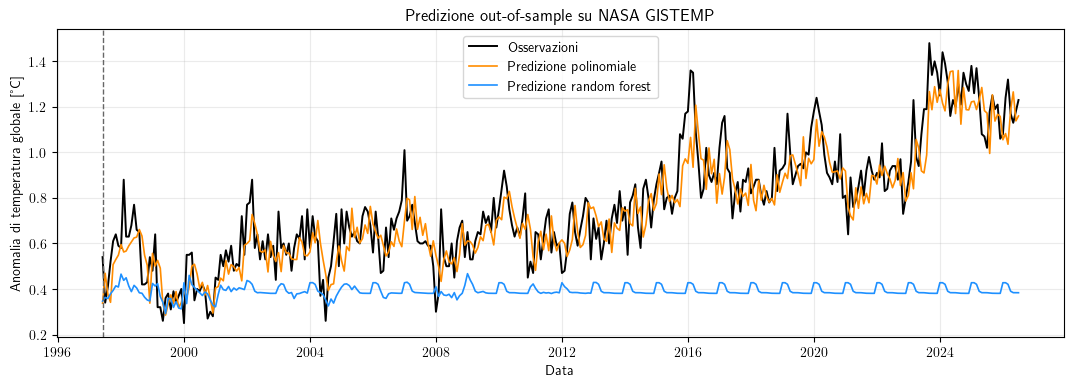

In [56]:
test = prediction["test"]

fig, ax = plt.subplots(figsize=(13, 4))

ax.plot(
    test["date"],
    test["anomaly"],
    color="black",
    linewidth=1.4,
    label="Osservazioni",
)

ax.plot(
    test["date"],
    prediction["predictions"]["polynomial"],
    color="darkorange",
    linewidth=1.2,
    label="Predizione polinomiale",
)

ax.plot(
    test["date"],
    prediction["predictions"]["random_forest"],
    color="dodgerblue",
    linewidth=1.2,
    label="Predizione random forest",
)

ax.axvline(
    test["date"].iloc[0],
    color="0.4",
    linestyle="--",
    linewidth=1.0,
)

ax.plot(dpi = 1000)

ax.set_xlabel("Data")
ax.set_ylabel("Anomalia di temperatura globale [°C]")
ax.set_title("Predizione out-of-sample su NASA GISTEMP")
ax.grid(alpha=0.25)
ax.legend()

plt.show()
